# Deep Learning Diabetes Prediction Project
This notebook contains the complete training pipeline for the Artificial Neural Network (ANN) that predicts diabetes based on medical records.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pickle

## 1. Data Loading and Preprocessing
We handle missing values by replacing zeroes with NaNs and filling them with the median of each respective column.

In [2]:
# Load dataset
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv("diabetes.csv", header=None, names=columns)

# Handle missing/invalid zero values
medical_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[medical_cols] = df[medical_cols].replace(0, np.nan)
df[medical_cols] = df[medical_cols].fillna(df[medical_cols].median())

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Train-Test Split and Standardization

In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the Streamlit app
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## 3. Building the ANN Model

In [4]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(12, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Training the Model

In [5]:
history = model.fit(
    X_train_scaled, y_train, 
    epochs=150, 
    batch_size=10, 
    validation_split=0.2, 
    verbose=1
)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5886 - loss: 0.6821 - val_accuracy: 0.6260 - val_loss: 0.6097
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6497 - loss: 0.6109 - val_accuracy: 0.6423 - val_loss: 0.5662
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6843 - loss: 0.5689 - val_accuracy: 0.6992 - val_loss: 0.5374
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7332 - loss: 0.5399 - val_accuracy: 0.7236 - val_loss: 0.5175
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7332 - loss: 0.5186 - val_accuracy: 0.7642 - val_loss: 0.5024
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7576 - loss: 0.5007 - val_accuracy: 0.7805 - val_loss: 0.4884
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7637 - loss: 0.4858 - val_accuracy: 0.7967 - val_loss: 0.4763
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7699 - loss: 0.4765 - val_accuracy: 0.7886 - 

## 5. Evaluation and Metrics

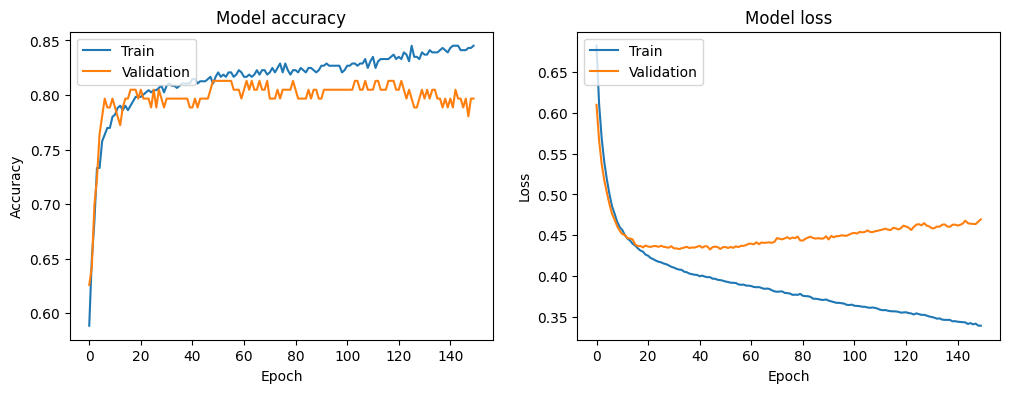

Test Accuracy: 0.7208
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
Confusion Matrix:
[[81 19]
 [24 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       100
           1       0.61      0.56      0.58        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.72      0.72      0.72       154

ROC-AUC Score: 0.8354


In [6]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate on test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

try:
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
except Exception as e:
    print(e)

## 6. Saving the Model

In [7]:
model.save("diabetes_model.keras")
print("Model saved as diabetes_model.keras")

Model saved as diabetes_model.keras
